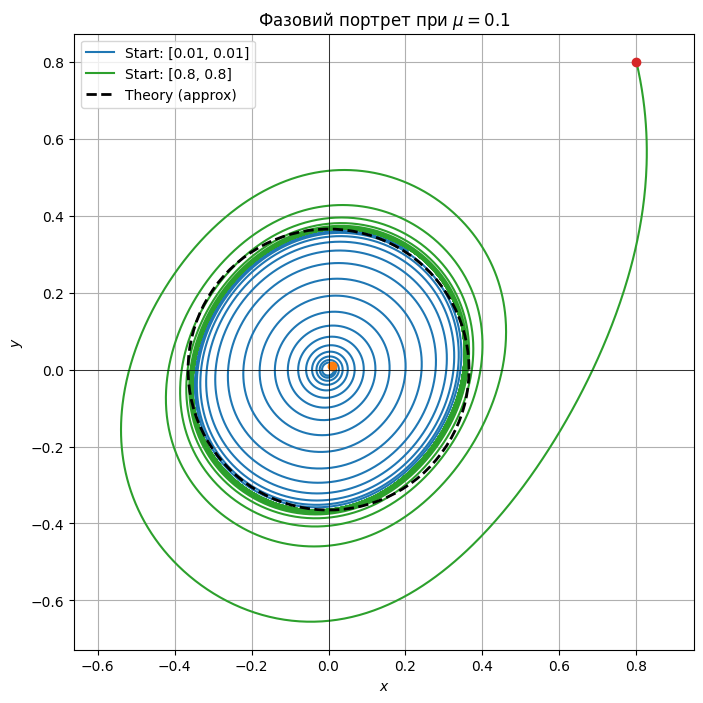

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Визначаємо систему
def system(state, t, mu):
    x, y = state
    dxdt = y - x**3
    dydt = -x + mu*y - x*(y**2)
    return [dxdt, dydt]

# Час симуляції
t = np.linspace(0, 100, 10000)

# Параметр mu (більше 0 для виникнення циклу)
mu = 0.1

# Початкові умови
initial_conditions = [
    [0.01, 0.01],   # Старт зсередини (близько до центру)
    [0.8, 0.8]    # Старт ззовні
]

plt.figure(figsize=(8, 8))

# Малюємо траєкторії
for ic in initial_conditions:
    solution = odeint(system, ic, t, args=(mu,))
    x = solution[:, 0]
    y = solution[:, 1]

    plt.plot(x, y, label=f'Start: {ic}')

    # Позначимо точку старту
    plt.plot(ic[0], ic[1], 'o')

# Теоретичний граничний цикл (коло радіусом r)
theta = np.linspace(0, 2*np.pi, 100)
r_theoretical = np.sqrt((4/3) * mu)
x_circle = r_theoretical * np.cos(theta)
y_circle = r_theoretical * np.sin(theta)

plt.plot(x_circle, y_circle, 'k--', linewidth=2, label='Theory (approx)')

plt.title(rf'Фазовий портрет при $\mu={mu}$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()